Tensors are the fundamental data structure in PyTorch. They are multidimensional arrays similar to NumPy arrays, but with the added benefits of GPU acceleration and automatic differentiation.

In the examples below, we will explore how PyTorch tensors compare to NumPy arrays.

In [1]:
import numpy as np
import torch

We will demonstrate how to create NumPy arrays and PyTorch tensors using various methods.

In [2]:
#create a 1-d numpy array and 1-d torch tensor
a1 = np.array([1, 2, 3])
b1 = torch.tensor([1, 2, 3])
print(f'a1: {a1}')
print(f'b1: {b1}')

#create a 2-d numpy array and 2-d torch tensor
a2 = np.array([[1, 2], [3, 4]])
b2 = torch.tensor([[1, 2], [3, 4]])
print(f'a2:\n{a2}')
print(f'b2:\n{b2}')

#a matrix with normal values
a3 = np.random.normal(0, 1, (2, 3))
b3 = torch.randn(2, 3)
print(f'a3:\n{a3}')
print(f'b3:\n{b3}')

#zeros
a4 = np.zeros((2, 3))
b4 = torch.zeros(2, 3)
print(f'a4:\n{a4}')
print(f'b4:\n{b4}')

#ones
a5 = np.ones((2, 3))
b5 = torch.ones(2, 3)
print(f'a5:\n{a5}')
print(f'b5:\n{b5}')

a1: [1 2 3]
b1: tensor([1, 2, 3])
a2:
[[1 2]
 [3 4]]
b2:
tensor([[1, 2],
        [3, 4]])
a3:
[[ 0.21070648  0.2153307   0.97263566]
 [-0.5227355   0.22343344 -0.84264981]]
b3:
tensor([[-0.1950,  0.2992, -0.9869],
        [ 0.7491,  0.2807,  0.8006]])
a4:
[[0. 0. 0.]
 [0. 0. 0.]]
b4:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
a5:
[[1. 1. 1.]
 [1. 1. 1.]]
b5:
tensor([[1., 1., 1.],
        [1., 1., 1.]])


We use a3, a4 and b3, b4 to demonstrate operations

In [3]:
print(f'NumPy Addition: \n {a3+a4}')
print(f'Torch Addition: \n {b3+b4}')

print(f'Numpy Element-wise Multiplication: \n {a3*a4}')
print(f'Torch Element-wise Multiplication: \n {b3*b4}')

print(f'NumPy Matrix Multiplication: \n {a3 @ a4.T}')
print(f'Torch Matrix Multiplication: \n {b3 @ b4.T}')

NumPy Addition: 
 [[ 0.21070648  0.2153307   0.97263566]
 [-0.5227355   0.22343344 -0.84264981]]
Torch Addition: 
 tensor([[-0.1950,  0.2992, -0.9869],
        [ 0.7491,  0.2807,  0.8006]])
Numpy Element-wise Multiplication: 
 [[ 0.  0.  0.]
 [-0.  0. -0.]]
Torch Element-wise Multiplication: 
 tensor([[-0., 0., -0.],
        [0., 0., 0.]])
NumPy Matrix Multiplication: 
 [[0. 0.]
 [0. 0.]]
Torch Matrix Multiplication: 
 tensor([[0., 0.],
        [0., 0.]])


Next, we will learn some other things, like how to convert a NumPy array to Torch Tensor, and how to reshape a tensor.

In [4]:
# convert a1 to a torch tensor
b1_from_a1 = torch.from_numpy(a1)
print(f'b1_from_a1: \n {b1_from_a1}')

# convert b1 to a numpy array
a1_from_b1 = b1.numpy()
print(f'a1_from_b1: \n {a1_from_b1}')

# reshape a1 to (3, 1) and convert to torch tensor
print(f'shape of b1: {b1.shape}')
b1_reshaped = b1.reshape(3, 1)
print(f'shape of b1_reshaped: {b1_reshaped.shape}')
print(f'b1_reshaped:\n{b1_reshaped}')

b1_from_a1: 
 tensor([1, 2, 3])
a1_from_b1: 
 [1 2 3]
shape of b1: torch.Size([3])
shape of b1_reshaped: torch.Size([3, 1])
b1_reshaped:
tensor([[1],
        [2],
        [3]])


The advantage of tensor compared to NumPy array is the __autograd__. 
Autograd is PyTorch's automatic differentiation system. It automatically computes gradients for tensors, which is essential for training neural networks using backpropagation.

In [5]:
print("=== Automatic Differentiation ===")

# Create a tensor with gradient tracking
x = torch.tensor(2.0, requires_grad=True)
print(f"x = {x}")
print(f'dy/dx = {x.grad}')

# Define a function y = x^2 + 3x + 1
y = x**2 + 3*x + 1
print(f"y = x^2 + 3x + 1 = {y}")

# Compute gradient dy/dx
y.backward()
print(f"x = {x}")
print(f"dy/dx = 2x + 3 = {x.grad}")  # Should be 2*2 + 3 = 7


=== Automatic Differentiation ===
x = 2.0
dy/dx = None
y = x^2 + 3x + 1 = 11.0
x = 2.0
dy/dx = 2x + 3 = 7.0


In [6]:

# Example with multiple variables
x1 = torch.tensor(1.0, requires_grad=True)
x2 = torch.tensor(2.0, requires_grad=True)

# Function: z = x1^2 + x2^3
z = x1**2 + x2**3
z.backward()


print(f"\nFor z = x1^2 + x2^3:")
print(f"dz/dx1 = 2*x1 = {x1.grad}")  # Should be 2*1 = 2
print(f"dz/dx2 = 3*x2^2 = {x2.grad}")  # Should be 3*2^2 = 12


# Example with vectors
print("\n=== Vector Gradients ===")
x_vec = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y_vec = torch.sum(x_vec**2)  # Sum of squares
y_vec.backward()
print(f"x = {x_vec}")
print(f"y = sum(x^2) = {y_vec}")
print(f"dy/dx = 2x = {x_vec.grad}")  # Should be [2, 4, 6]


For z = x1^2 + x2^3:
dz/dx1 = 2*x1 = 2.0
dz/dx2 = 3*x2^2 = 12.0

=== Vector Gradients ===
x = tensor([1., 2., 3.], requires_grad=True)
y = sum(x^2) = 14.0
dy/dx = 2x = tensor([2., 4., 6.])


autograd at __nonsmooth points__

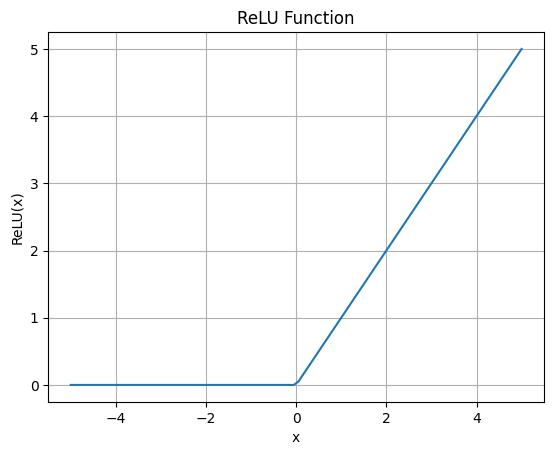

In [7]:
x = torch.tensor(0.0, requires_grad=True)
# define a relu function
y = torch.relu(x)
#plot the relu function
import matplotlib.pyplot as plt
x_vals = torch.linspace(-5, 5, 100)
y_vals = torch.relu(x_vals)
plt.plot(x_vals.numpy(), y_vals.numpy())
plt.title('ReLU Function')
plt.xlabel('x')
plt.ylabel('ReLU(x)')
plt.grid()
plt.show()

In [8]:
# by math definition, the gradient of relu at x=0 is undefined. But PyTorch defines it as 0. 
y.backward()
print(f"At x=0, dy/dx = {x.grad}")  # Should be 0 according to PyTorch, but mathematically it's undefined. 

At x=0, dy/dx = 0.0


In [9]:
x = torch.tensor(0.0, requires_grad=True)
# Define an absolution function
y = torch.abs(x)

# Compute gradient dy/dx
y.backward()
print(f"At x=0, dy/dx = {x.grad}")  # Should be 0 according to PyTorch, but mathematically it's undefined. 


At x=0, dy/dx = 0.0


In [16]:
# an example for grad function
x = torch.tensor([2.0], requires_grad=True)
y = x**2 + 3*x + 1
dy_dx = torch.autograd.grad(y, x)[0]
print(f"dy/dx = {dy_dx}")  # Should be 2*2 + 3 = 7
print(f'shape of dy/dx: {dy_dx[0].shape}')  # Should be torch.Size([1])

dy/dx = tensor([7.])
shape of dy/dx: torch.Size([])


In [18]:
# an examle for grad function with a list of tensors
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
y = x**2 + 3*x + 1
dy_dx = torch.autograd.grad(y.sum(), x)[0]
print(f"dy/dx = {dy_dx}")  # Should be [2*1 + 3, 2*2 + 3, 2*3 + 3]

dy/dx = tensor([5., 7., 9.])


Consider function of $$y: \mathbb R^2 \mapsto \mathbb R$$ given by
$$y(x) = x_1^2 + x_2^2.$$
Next, we want to evaluate multiple points at [1,2] and [3,4].

In [29]:
# an example of 2d function
y = lambda x: torch.sum(x**2, dim=1)
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]], requires_grad=True)

# print(f'y:\n{y(x)}')  # tensor([ 5., 25.], grad_fn=...)
dy_dx = torch.autograd.grad(y(x).sum(), x)[0]
print(f"dy/dx:\n{dy_dx}")  # Should be [[2*1, 2*2], [2*3, 2*4]] = [[2, 4], [6, 8]]

dy/dx:
tensor([[2., 4.],
        [6., 8.]])
